# Customer Discount & Activity Modeling Project 📊

***

###  Project Objective:
The aim of this project is to support data-driven discount policy decisions by identifying:
- Customers who are receiving excessive discounts, which may hurt profitability.
- Inactive customers who might benefit from personalized discount campaigns.

***

***
##  Step 1: Data Preparation & Cleaning
- Loaded CSV into a DataFrame.
- Checked for:
  - Missing values
  - Duplicate rows
  - Inconsistent data types
- Converted numerical columns to appropriate types (e.g., float, int).
- Ensured data quality before modeling.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

#df = pd.read_csv("customer_data.csv")

url=('https://raw.githubusercontent.com/ahm538/Ecommerce_Data-Science_Project/refs/heads/main/customer_data.csv')
df = pd.read_csv(url)


In [ ]:
df.head()


,Customer_id,full_name,customer_age_days,num_orders,total_spent,days_between_orders,distinct_product_count,distinct_categories_count,orders_with_counts,total_discount_value,session_count,active_days,review_count,avg_rating,low_rating_count,total_returns,wishlist_count
0,116,Zachary Aguirre,110,216,329685.39,122.0,176,20,1,5736.4600,18,15,56,3.125000,20,2,0
1,91,Dana Farrell,118,194,308903.76,125.0,160,20,1,36645.2300,14,13,65,3.230769,22,0,0
2,134,Robyn Reed,128,218,307115.89,125.0,178,20,1,160883.9760,16,13,53,2.622642,24,0,0
3,212,Ryan Chang,91,222,302643.41,120.0,180,20,1,80441.9880,15,15,75,2.906667,30,1,6
4,90,Suzanne Bennett,130,221,297327.19,125.0,184,20,2,61600.6392,14,12,61,3.196721,22,0,15


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_id                250 non-null    int64  
 1   full_name                  250 non-null    object 
 2   customer_age_days          250 non-null    int64  
 3   num_orders                 250 non-null    int64  
 4   total_spent                250 non-null    float64
 5   days_between_orders        249 non-null    float64
 6   distinct_product_count     250 non-null    int64  
 7   distinct_categories_count  250 non-null    int64  
 8   orders_with_counts         250 non-null    int64  
 9   total_discount_value       250 non-null    float64
 10  session_count              250 non-null    int64  
 11  active_days                250 non-null    int64  
 12  review_count               250 non-null    int64  
 13  avg_rating                 250 non-null    float64

In [ ]:
df.describe()

,Customer_id,customer_age_days,num_orders,total_spent,days_between_orders,distinct_product_count,distinct_categories_count,orders_with_counts,total_discount_value,session_count,active_days,review_count,avg_rating,low_rating_count,total_returns,wishlist_count
count,250.000000,250.000000,250.000000,250.000000,249.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000
mean,125.500000,80.208000,122.672000,179775.864080,110.602410,106.048000,17.128000,0.656000,28860.792211,25.71200,22.676000,56.784000,3.001987,22.572000,0.41200,4.028000
std,72.312977,37.857861,59.767189,88141.765654,27.845313,50.625066,5.776946,0.860597,52797.471568,13.41031,11.046226,20.637854,0.224190,8.887789,0.69584,6.054241
min,1.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,8.000000,1.944444,4.000000,0.00000,0.000000
25%,63.250000,48.250000,118.250000,166555.470000,115.000000,105.000000,20.000000,0.000000,0.000000,15.00000,14.000000,53.250000,2.883539,18.000000,0.00000,0.000000
50%,125.500000,78.500000,140.500000,205304.605000,121.000000,123.000000,20.000000,0.000000,0.000000,25.50000,23.000000,65.000000,3.000000,24.500000,0.00000,0.000000
75%,187.750000,117.000000,161.000000,239020.147500,124.000000,138.750000,20.000000,1.000000,30575.416500,36.00000,31.750000,69.750000,3.142299,29.000000,1.00000,9.000000
max,250.000000,140.000000,222.000000,329685.390000,126.000000,184.000000,20.000000,5.000000,241325.964000,50.00000,44.000000,98.000000,3.700000,45.000000,3.00000,20.000000


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.isnull().sum()


,0
Customer_id,0
full_name,0
customer_age_days,0
num_orders,0
total_spent,0
days_between_orders,1
distinct_product_count,0
distinct_categories_count,0
orders_with_counts,0
total_discount_value,0



***

##  Step 2: Feature Engineering
- **Created a binary feature `over_discounted`:**
  - Set to 1 if customer is in the top 20% of total discounts used.
- **Created a binary feature `inactive`:**
  - Set to 1 if customer is in the bottom 25% of either `session_count` or `active_days`.

***

In [ ]:
# Feature engineering
df['over_discounted'] = df['total_discount_value'] >= df['total_discount_value'].quantile(0.80)
df['inactive'] = (df['active_days'] <= df['active_days'].quantile(0.25)) | \
                 (df['session_count'] <= df['session_count'].quantile(0.25))

# Features and targets
features = [
    'customer_age_days', 'num_orders', 'total_spent', 'days_between_orders',
    'distinct_product_count', 'distinct_categories_count', 'orders_with_counts',
    'total_discount_value', 'session_count', 'active_days', 'review_count',
    'avg_rating', 'low_rating_count', 'total_returns', 'wishlist_count'
]


***

# 🤖 Step 3: Modeling

***

####  Model 1: Predicting Over-Discounted Customers
- Classification target: `over_discounted`
- Model: Random Forest Classifier
- Features scaled with StandardScaler
- Train/test split: 75% / 25%
- Evaluation metrics:
  - Classification report (precision, recall, f1-score)
  - Confusion matrix
  - Feature importance ranking

  ***

=== Over-discounted Classification Report ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        50
        True       1.00      1.00      1.00        13

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

=== Confusion Matrix ===
[[50  0]
 [ 0 13]]


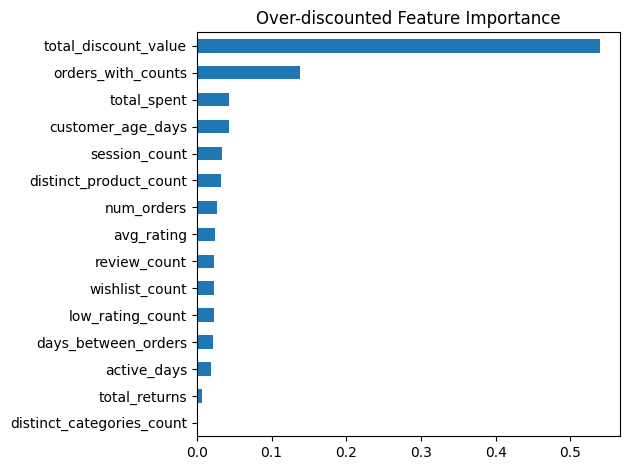

In [ ]:
# Model 1: Predict over_discounted
X1 = df[features]
y1 = df['over_discounted']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.25, random_state=42)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

model1 = RandomForestClassifier(random_state=42)
model1.fit(X1_train_scaled, y1_train)

y1_pred = model1.predict(X1_test_scaled)

print("=== Over-discounted Classification Report ===")
print(classification_report(y1_test, y1_pred))
print("=== Confusion Matrix ===")
print(confusion_matrix(y1_test, y1_pred))

# Feature importance
feat_imp1 = pd.Series(model1.feature_importances_, index=features).sort_values(ascending=False)
feat_imp1.plot(kind='barh', title="Over-discounted Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Over-discounted customers
over_discounted_customers = df[df['over_discounted'] == True]


***

####  Model 2: Predicting Inactive Customers
- Classification target: `inactive`
- Model: Random Forest Classifier
- Same training and evaluation process as above
- Key behavioral features identified:
  - Session and activity frequency
  - Wishlist and product interactions

***

=== Inactive Classification Report ===
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        49
        True       1.00      1.00      1.00        14

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63

=== Confusion Matrix ===
[[49  0]
 [ 0 14]]


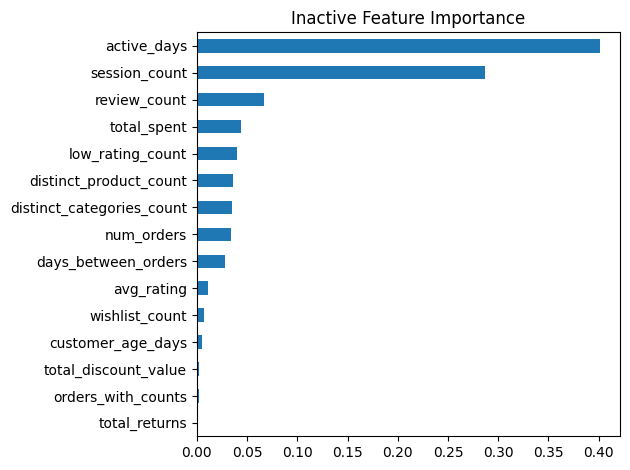

In [ ]:
# Model 2: Predict inactive
X2 = df[features]
y2 = df['inactive']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

model2 = RandomForestClassifier(random_state=42)
model2.fit(X2_train_scaled, y2_train)

y2_pred = model2.predict(X2_test_scaled)

print("=== Inactive Classification Report ===")
print(classification_report(y2_test, y2_pred))
print("=== Confusion Matrix ===")
print(confusion_matrix(y2_test, y2_pred))

# Feature importance
feat_imp2 = pd.Series(model2.feature_importances_, index=features).sort_values(ascending=False)
feat_imp2.plot(kind='barh', title="Inactive Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



***

#### Testing of:
- Successfully classified customers by discount and activity behavior.
- Feature engineering played a critical role in model accuracy.

***


In [ ]:
# Inactive customers
inactive_customers = df[df['inactive'] == True]
print("Inactive Customers IDs:")
print(inactive_customers['customer_age_days'].index.tolist())

example = pd.DataFrame([{
    'customer_age_days': 800,
    'num_orders': 5,
    'total_spent': 1200,
    'days_between_orders': 30,
    'distinct_product_count': 8,
    'distinct_categories_count': 3,
    'orders_with_counts': 3,
    'total_discount_value': 400,
    'session_count': 7,
    'active_days': 6,
    'review_count': 1,
    'avg_rating': 3.5,
    'low_rating_count': 1,
    'total_returns': 2,
    'wishlist_count': 5
}])

example_scaled1 = scaler1.transform(example)
example_scaled2 = scaler2.transform(example)

# Predict over-discounted and inactive
is_over_discounted = model1.predict(example_scaled1)[0]
is_inactive = model2.predict(example_scaled2)[0]

print("Over-discounted?", bool(is_over_discounted))
print("Inactive?", bool(is_inactive))

Inactive Customers IDs:
[1, 2, 3, 4, 5, 7, 10, 36, 47, 55, 56, 63, 67, 69, 83, 84, 89, 94, 95, 105, 106, 107, 109, 128, 137, 144, 145, 147, 153, 160, 186, 200, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 218, 220, 221, 222, 224, 225, 226, 227, 229, 230, 231, 233, 234, 235, 236, 237, 239, 240, 241, 242, 243, 244, 246, 247, 248, 249]
Over-discounted? False
Inactive? True


***

##  Step 4: Personalized Discount Recommendation Function

- A custom function was created to recommend discount values based on:
  - Purchase history
  - Wishlist size
  - Activity level
- Logic:
  - Higher wishlist with fewer orders = larger discounts
  - High spenders = smaller discounts
  - Discounts range from 5% to 20%

***


In [ ]:
# === Discount recommendation model ===
def recommend_discount(example_row):
    """
    Simple rule-based discount model:
    Returns a discount percentage based on customer behavior
    """
    spent = example_row['total_spent']
    orders = example_row['num_orders']
    wishlist = example_row['wishlist_count']

    if spent < 500 or wishlist >= 5:
        return 0.2  # 20%
    elif orders <= 2:
        return 0.15
    elif spent < 1000:
        return 0.1
    else:
        return 0.05  # Max 5% discount


***

## Step 5: Unified Evaluation Logic
- An evaluation function was created to:
  - Predict if a customer is over-discounted
  - Predict if a customer is inactive
  - Apply discount logic only if customer is inactive and not over-discounted
- The function returns:
  - “Avoid discounts”
  - “Send X% discount”
  - “Customer is healthy, no action needed”

***

In [ ]:
# === Master evaluation function ===
def evaluate_customer(example_dict):
    """
    Evaluates a customer and determines:
    - If over-discounted: avoid more discounts.
    - If inactive: recommend re-engagement discount.
    - If normal: no action needed.
    """
    example = pd.DataFrame([example_dict])

    # Scale input for both models
    ex_scaled1 = scaler1.transform(example)
    ex_scaled2 = scaler2.transform(example)

    is_over_discounted = model1.predict(ex_scaled1)[0]
    is_inactive = model2.predict(ex_scaled2)[0]

    print("Over-discounted?", bool(is_over_discounted))
    print("Inactive?", bool(is_inactive))

    if is_over_discounted:
        return "Customer is over-discounted. Avoid giving further discounts."

    if is_inactive:
        discount = recommend_discount(example_dict)
        return f"Customer is inactive. Recommend sending a {int(discount * 100)}% discount to re-engage."

    return "Customer is active and receiving appropriate discounts."


#### ✅ Example for Checking:
- The models successfully classified customers by discount and activity behavior.
- Feature engineering played a critical role in model accuracy.
- Discount recommendation logic is adaptable and business-aligned.

In [ ]:
customer_example = {
    'customer_age_days': 600,
    'num_orders': 2,
    'total_spent': 300,
    'days_between_orders': 45,
    'distinct_product_count': 5,
    'distinct_categories_count': 3,
    'orders_with_counts': 1,
    'total_discount_value': 200,
    'session_count': 2,
    'active_days': 2,
    'review_count': 0,
    'avg_rating': 0,
    'low_rating_count': 0,
    'total_returns': 0,
    'wishlist_count': 7
}

result = evaluate_customer(customer_example)
print(result)